# Final Model Comparison

## Objective
To compare baseline performance with filter-based and wrapper-based 
dimensionality reduction techniques across multiple classifiers.

This notebook identifies:
- The best dimensionality reduction method
- The best performing classifier
- The impact of feature reduction on model performance

In [1]:
import pandas as pd

baseline = pd.read_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\results\baseline_results.csv")
filter_results = pd.read_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\results\filter_results.csv")
wrapper_results = pd.read_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\results\wrapper_results.csv")

In [2]:
baseline["Method"] = "Baseline"

In [3]:
all_results = pd.concat([
    baseline,
    filter_results,
    wrapper_results
])

all_results.head()

,Model,Accuracy,Precision,F1 Score,ROC-AUC,Method
0,Random Forest,0.956140,0.958904,0.965517,0.993882,Baseline
1,Decision Tree,0.912281,0.955882,0.928571,0.915675,Baseline
2,SVM,0.982456,0.986111,0.986111,0.995040,Baseline
3,Naive Bayes,0.929825,0.944444,0.944444,0.986772,Baseline
4,KNN,0.956140,0.958904,0.965517,0.978836,Baseline


In [4]:
all_results[["Accuracy","Precision","F1 Score","ROC-AUC"]] = \
    all_results[["Accuracy","Precision","F1 Score","ROC-AUC"]].round(3)

all_results

,Model,Accuracy,Precision,F1 Score,ROC-AUC,Method
0,Random Forest,0.956,0.959,0.966,0.994,Baseline
1,Decision Tree,0.912,0.956,0.929,0.916,Baseline
2,SVM,0.982,0.986,0.986,0.995,Baseline
3,Naive Bayes,0.930,0.944,0.944,0.987,Baseline
4,KNN,0.956,0.959,0.966,0.979,Baseline
0,Random Forest,0.947,0.946,0.959,0.992,Correlation
1,Decision Tree,0.912,0.919,0.932,0.901,Correlation
2,SVM,0.965,0.986,0.972,0.996,Correlation
3,Naive Bayes,0.886,0.928,0.908,0.953,Correlation
4,KNN,0.965,0.972,0.972,0.995,Correlation


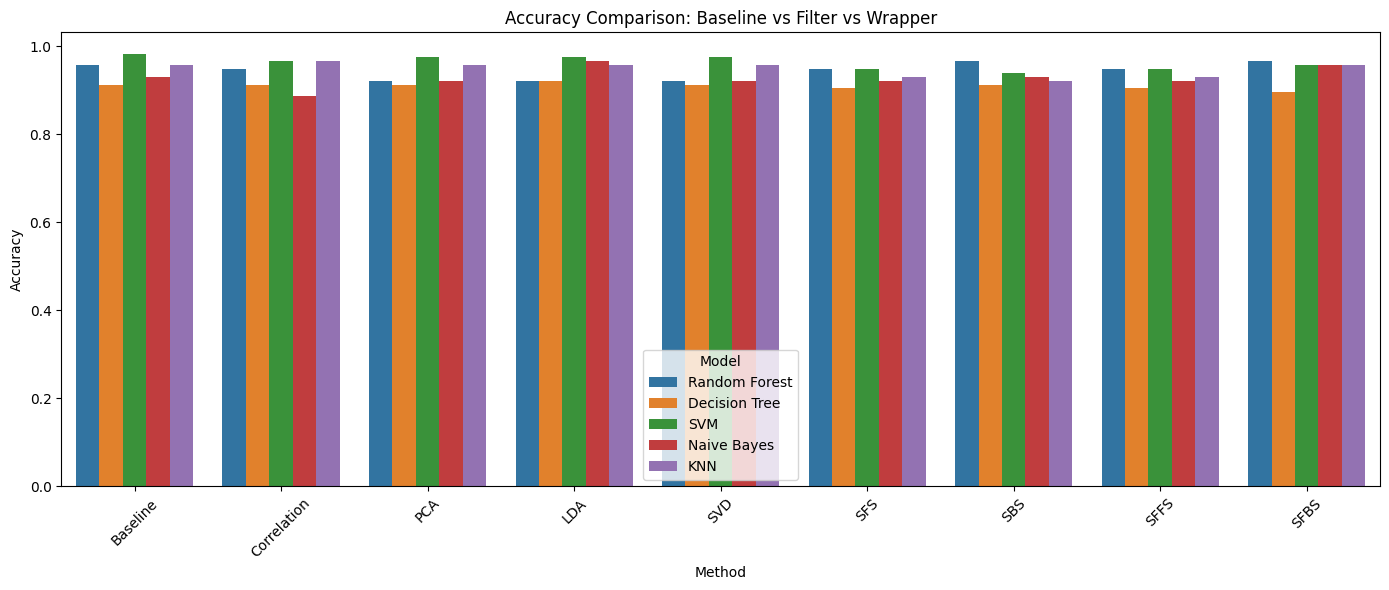

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.barplot(data=all_results, x="Method", y="Accuracy", hue="Model")
plt.title("Accuracy Comparison: Baseline vs Filter vs Wrapper")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

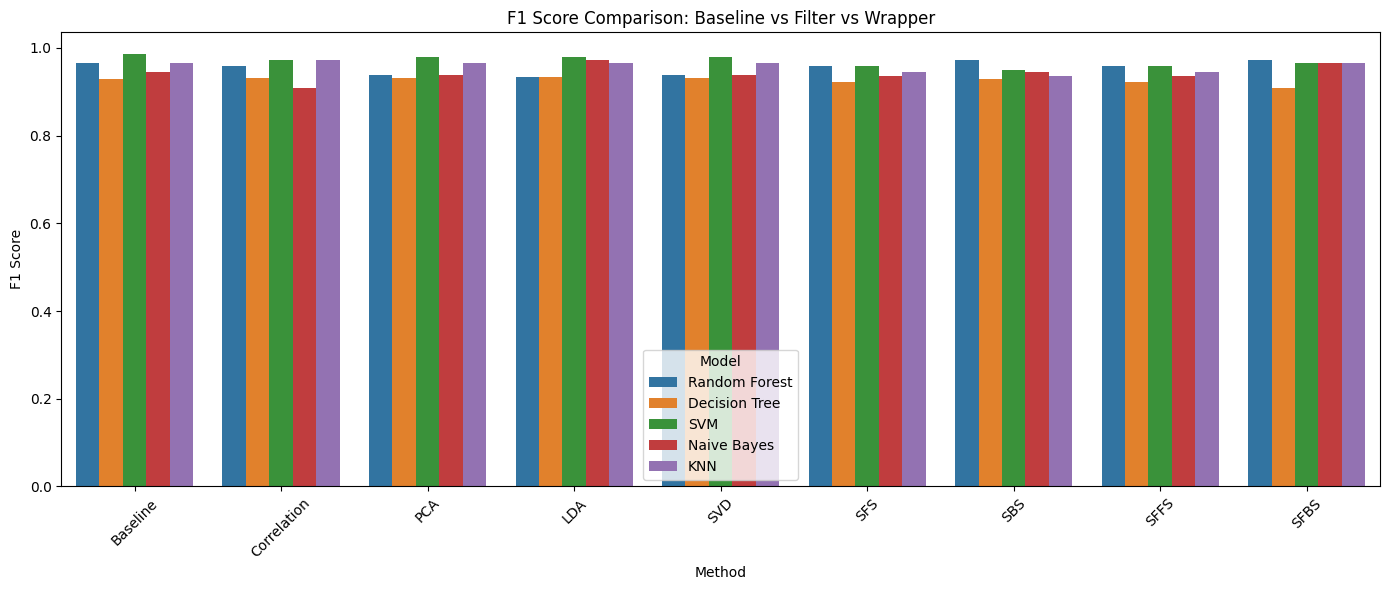

In [7]:
plt.figure(figsize=(14,6))
sns.barplot(data=all_results, x="Method", y="F1 Score", hue="Model")
plt.title("F1 Score Comparison: Baseline vs Filter vs Wrapper")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

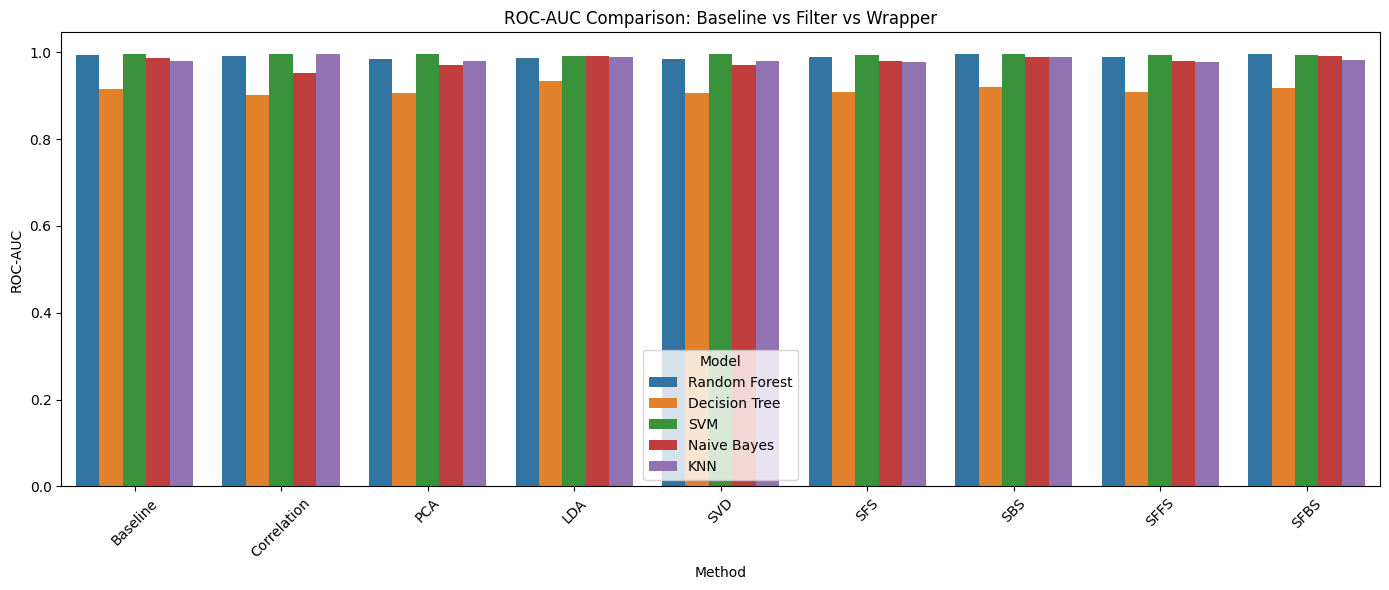

In [8]:
plt.figure(figsize=(14,6))
sns.barplot(data=all_results, x="Method", y="ROC-AUC", hue="Model")
plt.title("ROC-AUC Comparison: Baseline vs Filter vs Wrapper")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
best_per_model = all_results.loc[
    all_results.groupby("Model")["Accuracy"].idxmax()
]

best_per_model

,Model,Accuracy,Precision,F1 Score,ROC-AUC,Method
11,Decision Tree,0.921,0.985,0.934,0.933,LDA
11,Decision Tree,0.904,0.955,0.921,0.909,SFFS
4,KNN,0.956,0.959,0.966,0.979,Baseline
4,KNN,0.965,0.972,0.972,0.995,Correlation
4,KNN,0.930,0.944,0.944,0.977,SFS
13,Naive Bayes,0.965,0.959,0.973,0.992,LDA
13,Naive Bayes,0.921,0.957,0.936,0.979,SFFS
5,Random Forest,0.921,0.944,0.937,0.985,PCA
5,Random Forest,0.965,0.972,0.972,0.995,SBS
2,SVM,0.982,0.986,0.986,0.995,Baseline


In [10]:
overall_best = all_results.loc[
    all_results["Accuracy"].idxmax()
]

overall_best

,Model,Accuracy,Precision,F1 Score,ROC-AUC,Method
2,SVM,0.982,0.986,0.986,0.995,Baseline
2,SVM,0.965,0.986,0.972,0.996,Correlation
2,SVM,0.947,0.971,0.958,0.993,SFS


In [11]:
baseline_accuracy = baseline.set_index("Model")["Accuracy"]

comparison = best_per_model.set_index("Model")["Accuracy"] - baseline_accuracy

comparison

Model
Decision Tree    0.008719
Decision Tree   -0.008281
KNN             -0.000140
KNN              0.008860
KNN             -0.026140
Naive Bayes      0.035175
Naive Bayes     -0.008825
Random Forest   -0.035140
Random Forest    0.008860
SVM             -0.000456
SVM             -0.017456
SVM             -0.035456
Name: Accuracy, dtype: float64

## Key Findings

1. The baseline SVM model using all 30 features achieved the highest overall Accuracy (0.982) and F1 Score (0.986).
2. Feature extraction methods such as PCA, LDA, and SVD preserved most of the predictive performance with only minor accuracy reduction.
3. Correlation-based feature selection achieved the highest ROC-AUC (0.996), indicating strong ranking performance despite a slight drop in accuracy.
4. Wrapper methods (SFS, SBS, SFFS, SFBS) reduced dimensionality but resulted in lower classification performance compared to the baseline.
5. Overall, dimensionality reduction did not significantly improve SVM performance for this dataset, suggesting that the original feature space is already highly discriminative.

In [12]:
svm_results = all_results[all_results["Model"] == "SVM"]
svm_results

,Model,Accuracy,Precision,F1 Score,ROC-AUC,Method
2,SVM,0.982,0.986,0.986,0.995,Baseline
2,SVM,0.965,0.986,0.972,0.996,Correlation
7,SVM,0.974,0.986,0.979,0.995,PCA
12,SVM,0.974,0.973,0.979,0.992,LDA
17,SVM,0.974,0.986,0.979,0.995,SVD
2,SVM,0.947,0.971,0.958,0.993,SFS
7,SVM,0.939,0.971,0.950,0.995,SBS
12,SVM,0.947,0.971,0.958,0.993,SFFS
17,SVM,0.956,0.972,0.965,0.993,SFBS


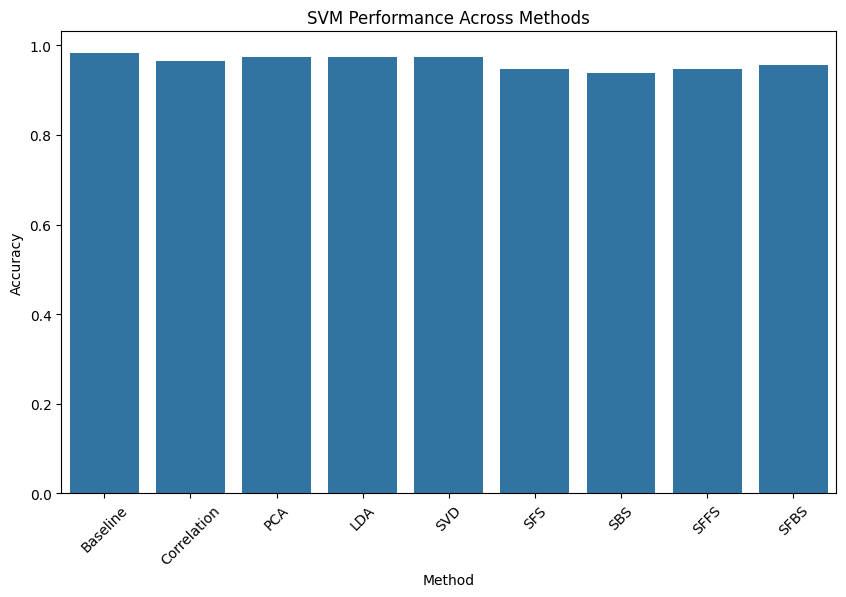

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=svm_results, x="Method", y="Accuracy")
plt.title("SVM Performance Across Methods")
plt.xticks(rotation=45)
plt.show()

## Final Observations

1. SVM achieved the highest overall baseline performance using all 30 original features.
2. Feature extraction methods such as PCA, LDA, and SVD preserved most of the classification performance with only a minor reduction in accuracy.
3. Correlation-based feature selection achieved the highest ROC-AUC, indicating strong ranking capability despite a slight drop in accuracy.
4. Wrapper methods (SFS, SBS, SFFS, SFBS) reduced feature dimensionality but did not outperform the baseline configuration.
5. Overall, dimensionality reduction did not significantly improve SVM performance for this dataset, suggesting that the original feature set is already highly discriminative.